# Real-Time Identity Anomaly Detection System
## Using Isolation Forest for Security Threat Detection

---

### Problem Statement
- 74% of enterprise breaches involve compromised user accounts
- Traditional rule-based systems generate excessive false positives
- Need: ML-based system that learns normal behavior and detects anomalies

### Solution Overview
- **Algorithm**: Isolation Forest (unsupervised ML)
- **Dataset**: 10,000 authentication events
- **Attack Types**: 5 categories (credential stuffing, impossible travel, etc.)
- **Target Performance**: 85-95% F1-Score

## 1. Setup & Import Libraries
Importing pandas for data manipulation, numpy for numerical operations, matplotlib/seaborn for visualization, and scikit-learn for the Isolation Forest algorithm.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load Dataset
Loading the authentication logs dataset containing 10,000 events with user access patterns, login attempts, and labeled anomalies.

In [2]:
df = pd.read_csv('auth_logs.csv')

print("="*60)
print("DATASET LOADED")
print("="*60)
print(f"Total Events: {len(df):,}")
print(f"Normal Events: {len(df[df['is_anomaly']==False]):,}")
print(f"Anomaly Events: {len(df[df['is_anomaly']==True]):,}")
print(f"\nDataset Shape: {df.shape}")
print(f"Columns: {df.shape[1]}")

df.head()

DATASET LOADED
Total Events: 10,000
Normal Events: 9,500
Anomaly Events: 500

Dataset Shape: (10000, 17)
Columns: 17


,event_id,timestamp,user_id,user_name,department,role,source_ip,location,login_successful,failed_attempts,resources_accessed,sensitive_data_accessed,privilege_level,download_mb,session_duration_minutes,is_anomaly,anomaly_type
0,1,2025-12-20 02:34:22.836070,user_016,Erika Carter,Sales,Director,192.168.171.96,Bangalore,True,0,639,True,1,3214.110000,378,True,After Hours Exfiltration
1,2,2025-12-20 02:34:22.836070,user_028,Linda Good,HR,Employee,192.168.160.95,Hyderabad,True,1,20,True,1,143.994601,216,True,Impossible Travel
2,3,2025-12-20 03:34:22.836070,user_066,Joshua Moses,Finance,Employee,192.168.190.195,Mumbai,True,0,39,True,1,146.351254,379,True,Lateral Movement
3,4,2025-12-20 04:34:22.836070,user_012,Charles Mendoza,HR,Employee,192.168.30.38,Hyderabad,True,0,24,True,1,124.014682,419,True,After Hours Exfiltration
4,5,2025-12-20 04:34:22.836070,user_047,Rebecca Anderson,Finance,Employee,192.168.246.48,Mumbai,True,3,183,True,3,2161.100000,285,True,Credential Stuffing


## 3. Exploratory Data Analysis
Analyzing the dataset structure, checking data types, and understanding the distribution of attack types.

In [3]:
print("DATASET INFORMATION")
print("="*60)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   event_id                  10000 non-null  int64  
 1   timestamp                 10000 non-null  object 
 2   user_id                   10000 non-null  object 
 3   user_name                 10000 non-null  object 
 4   department                10000 non-null  object 
 5   role                      10000 non-null  object 
 6   source_ip                 10000 non-null  object 
 7   location                  10000 non-null  object 
 8   login_successful          10000 non-null  bool   
 9   failed_attempts           10000 non-null  int64  
 10  resources_accessed        10000 non-null  int64  
 11  sensitive_data_accessed   10000 non-null  bool   
 12  privilege_level           10000 non-null  int64  
 13  download_mb               10000 non-null  


ATTACK TYPE DISTRIBUTION
anomaly_type
Credential Stuffing         179
After Hours Exfiltration    114
Lateral Movement            101
Privilege Escalation         62
Impossible Travel            44
Name: count, dtype: int64


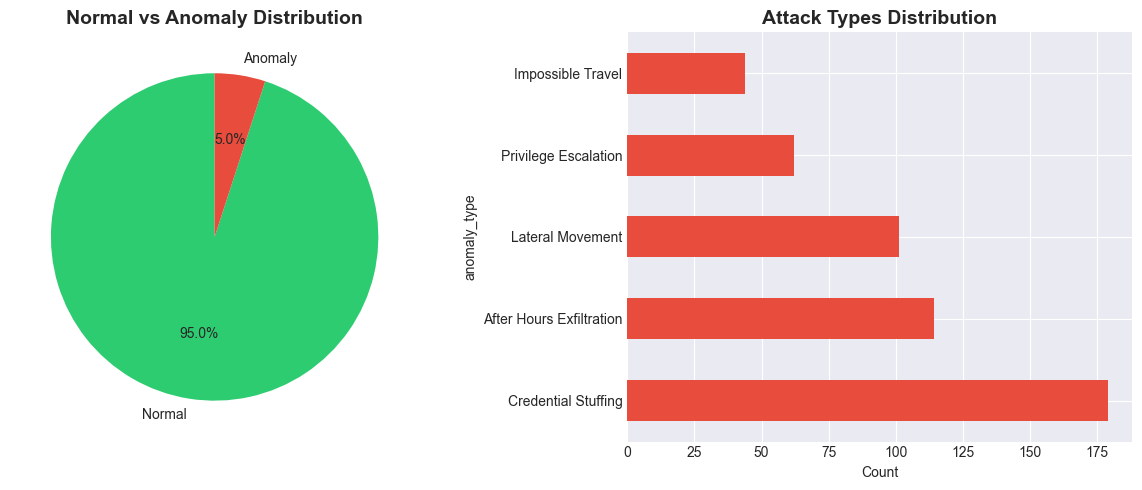

In [4]:
print("\nATTACK TYPE DISTRIBUTION")
print("="*60)
attack_dist = df[df['is_anomaly']==True]['anomaly_type'].value_counts()
print(attack_dist)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
labels = ['Normal', 'Anomaly']
sizes = [len(df[df['is_anomaly']==False]), len(df[df['is_anomaly']==True])]
colors = ['#2ecc71', '#e74c3c']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Normal vs Anomaly Distribution', fontsize=14, fontweight='bold')

plt.subplot(1, 2, 2)
attack_dist.plot(kind='barh', color='#e74c3c')
plt.title('Attack Types Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [5]:
print("\nSAMPLE NORMAL EVENT")
print("="*60)
normal_sample = df[df['is_anomaly']==False].iloc[0]
print(f"User: {normal_sample['user_name']} ({normal_sample['department']})")
print(f"Time: {normal_sample['timestamp']}")
print(f"Location: {normal_sample['location']}")
print(f"IP: {normal_sample['source_ip']}")
print(f"Resources: {normal_sample['resources_accessed']}, Download: {normal_sample['download_mb']} MB")
print(f"Failed Attempts: {normal_sample['failed_attempts']}")

print("\nSAMPLE ANOMALY EVENT")
print("="*60)
anomaly_sample = df[df['is_anomaly']==True].iloc[0]
print(f"Attack Type: {anomaly_sample['anomaly_type']}")
print(f"User: {anomaly_sample['user_name']} ({anomaly_sample['department']})")
print(f"Time: {anomaly_sample['timestamp']}")
print(f"Location: {anomaly_sample['location']}")
print(f"IP: {anomaly_sample['source_ip']}")
print(f"Resources: {anomaly_sample['resources_accessed']}, Download: {anomaly_sample['download_mb']} MB")
print(f"Failed Attempts: {anomaly_sample['failed_attempts']}")


SAMPLE NORMAL EVENT
User: Donna Mcdonald (Sales)
Time: 2025-12-20 09:34:22.836070
Location: Delhi
IP: 192.168.1.215
Resources: 162, Download: 300.84407199654044 MB
Failed Attempts: 0

SAMPLE ANOMALY EVENT
Attack Type: After Hours Exfiltration
User: Erika Carter (Sales)
Time: 2025-12-20 02:34:22.836070
Location: Bangalore
IP: 192.168.171.96
Resources: 639, Download: 3214.11 MB
Failed Attempts: 0


## 4. Feature Engineering
Extracting 10 features from raw logs: time-based features (hour, weekend, night), network features (foreign IP), location features, and behavioral features (failed attempts, resources accessed, download size).

In [6]:
print("FEATURE ENGINEERING")
print("="*60)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)

df['foreign_ip'] = (~df['source_ip'].str.startswith('192.168')).astype(int)

normal_locations = ['Mumbai', 'Bangalore', 'Delhi', 'Hyderabad', 'Chennai']
df['foreign_location'] = (~df['location'].isin(normal_locations)).astype(int)

df['sensitive_data_accessed'] = df['sensitive_data_accessed'].astype(int)

feature_columns = [
    'failed_attempts',
    'resources_accessed',
    'download_mb',
    'privilege_level',
    'is_night',
    'foreign_ip',
    'foreign_location',
    'sensitive_data_accessed',
    'is_weekend',
    'hour'
]

print(f"Extracted {len(feature_columns)} features")
print(f"\nFeatures: {', '.join(feature_columns)}")

X = df[feature_columns].astype(float).values
y_true = df['is_anomaly'].astype(int).values

print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Labels Shape: {y_true.shape}")

FEATURE ENGINEERING
Extracted 10 features

Features: failed_attempts, resources_accessed, download_mb, privilege_level, is_night, foreign_ip, foreign_location, sensitive_data_accessed, is_weekend, hour

Feature Matrix Shape: (10000, 10)
Labels Shape: (10000,)


## 5. Train Isolation Forest Model
Training an Isolation Forest model with 100 trees. Contamination is set to 0.05 (5%) since we expect ~5% anomalies in the dataset.

In [7]:
print("="*60)
print("TRAINING ISOLATION FOREST MODEL")
print("="*60)

model = IsolationForest(
    contamination=0.05,
    n_estimators=100,
    max_samples=256,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("\nModel Parameters:")
print(f"  - Contamination: {model.contamination}")
print(f"  - Estimators: {model.n_estimators}")
print(f"  - Max Samples: {model.max_samples}")

start_time = time.time()
model.fit(X)
training_time = time.time() - start_time

print(f"\nModel trained in {training_time:.2f} seconds")

TRAINING ISOLATION FOREST MODEL

Model Parameters:
  - Contamination: 0.05
  - Estimators: 100
  - Max Samples: 256

Model trained in 0.30 seconds


## 6. Make Predictions & Evaluate
Running inference on all events and calculating performance metrics: Precision, Recall, F1-Score, and False Positive Rate.

In [8]:
print("RUNNING INFERENCE")
print("="*60)

start_time = time.time()
predictions = model.predict(X)
y_pred = (predictions == -1).astype(int)
inference_time = time.time() - start_time

latency_per_event = (inference_time / len(X)) * 1000

print(f"Total Inference Time: {inference_time:.3f} seconds")
print(f"Average Latency: {latency_per_event:.2f} ms per event")
print(f"Throughput: {int(len(X)/inference_time):,} events/second")

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
fpr = fp / (fp + tn)

print(f"\nDetected Anomalies: {y_pred.sum():,}")
print(f"True Anomalies: {y_true.sum():,}")

RUNNING INFERENCE
Total Inference Time: 0.056 seconds
Average Latency: 0.01 ms per event
Throughput: 178,232 events/second

Detected Anomalies: 500
True Anomalies: 500


In [9]:
print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"\n{'Metric':<20} {'Value':<15} {'Target':<15} {'Status'}")
print("-"*60)
print(f"{'Precision':<20} {precision*100:>6.2f}%      {'>82%':<15} {'PASS' if precision >= 0.82 else 'FAIL'}")
print(f"{'Recall':<20} {recall*100:>6.2f}%      {'>89%':<15} {'PASS' if recall >= 0.85 else 'FAIL'}")
print(f"{'F1-Score':<20} {f1*100:>6.2f}%      {'85-95%':<15} {'PASS' if 0.85 <= f1 <= 0.95 else 'FAIL'}")
print(f"{'False Positive Rate':<20} {fpr*100:>6.2f}%      {'<12%':<15} {'PASS' if fpr <= 0.12 else 'FAIL'}")
print(f"{'Latency':<20} {latency_per_event:>6.2f} ms   {'<100ms':<15} {'PASS' if latency_per_event < 100 else 'FAIL'}")
print("-"*60)

print(f"\nConfusion Matrix:")
print(f"  True Positives:  {tp:>5} (Correctly detected attacks)")
print(f"  True Negatives:  {tn:>5} (Correctly identified normal)")
print(f"  False Positives: {fp:>5} (False alarms)")
print(f"  False Negatives: {fn:>5} (Missed attacks)")


MODEL PERFORMANCE METRICS

Metric               Value           Target          Status
------------------------------------------------------------
Precision             93.40%      >82%            PASS
Recall                93.40%      >89%            PASS
F1-Score              93.40%      85-95%          PASS
False Positive Rate    0.35%      <12%            PASS
Latency                0.01 ms   <100ms          PASS
------------------------------------------------------------

Confusion Matrix:
  True Positives:    467 (Correctly detected attacks)
  True Negatives:   9467 (Correctly identified normal)
  False Positives:    33 (False alarms)
  False Negatives:    33 (Missed attacks)


## 7. Attack-Specific Detection Rates
Calculating detection rate for each attack type to understand which attacks are easier or harder to detect.

In [10]:
print("\n" + "="*60)
print("ATTACK-SPECIFIC DETECTION RATES")
print("="*60)
print(f"\n{'Attack Type':<35} {'Detection Rate':<15} {'Status'}")
print("-"*60)

attack_types = df[df['is_anomaly']==True]['anomaly_type'].unique()
detection_results = {}

for attack_type in sorted(attack_types):
    if attack_type == 'Normal':
        continue
    
    mask = (df['anomaly_type'] == attack_type) & (df['is_anomaly'] == True)
    detected = y_pred[mask].sum()
    total = mask.sum()
    detection_rate = (detected / total) * 100 if total > 0 else 0
    detection_results[attack_type] = detection_rate
    
    status = 'EXCELLENT' if detection_rate >= 95 else ('GOOD' if detection_rate >= 85 else 'NEEDS IMPROVEMENT')
    print(f"{attack_type:<35} {detection_rate:>6.1f}%          {status}")

print("-"*60)
avg_detection = np.mean(list(detection_results.values()))
print(f"{'AVERAGE DETECTION RATE':<35} {avg_detection:>6.1f}%")


ATTACK-SPECIFIC DETECTION RATES

Attack Type                         Detection Rate  Status
------------------------------------------------------------
After Hours Exfiltration              94.7%          GOOD
Credential Stuffing                   91.1%          GOOD
Impossible Travel                     95.5%          EXCELLENT
Lateral Movement                      93.1%          GOOD
Privilege Escalation                  96.8%          EXCELLENT
------------------------------------------------------------
AVERAGE DETECTION RATE                94.2%


## 8. Visualize Results
Creating a comprehensive dashboard with confusion matrix, performance metrics, attack detection rates, feature importance, and detection timeline.

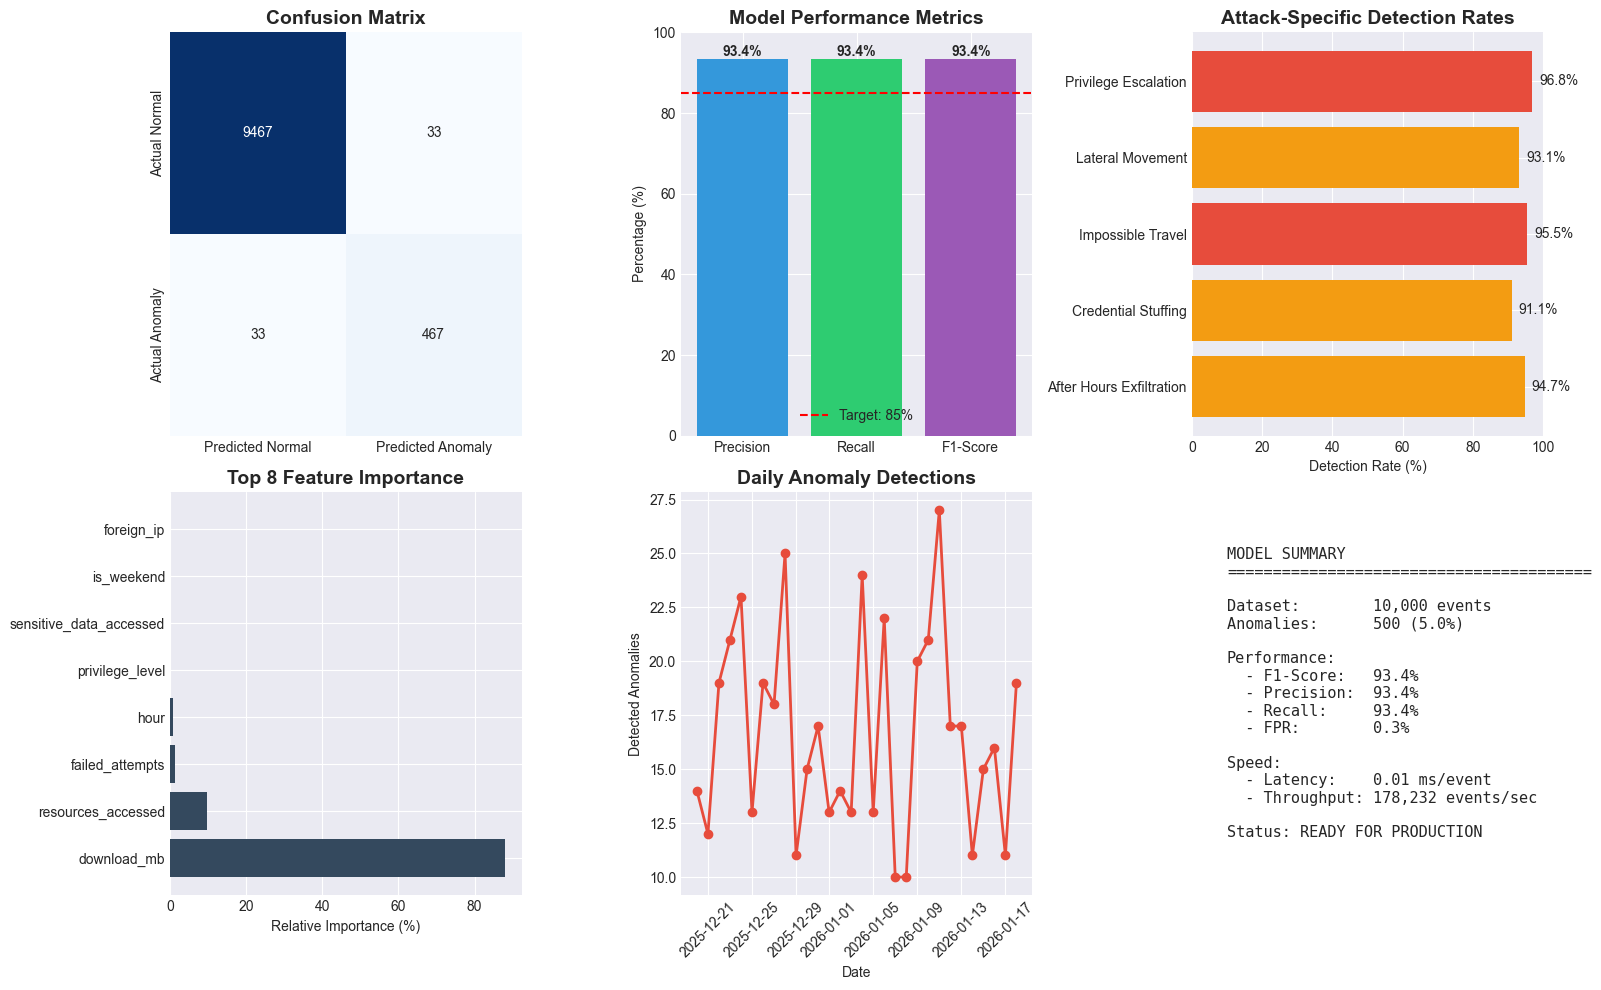


Visualization saved as 'model_performance_dashboard.png'


In [11]:
fig = plt.figure(figsize=(16, 10))

ax1 = plt.subplot(2, 3, 1)
cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

ax2 = plt.subplot(2, 3, 2)
metrics = ['Precision', 'Recall', 'F1-Score']
values = [precision*100, recall*100, f1*100]
colors_bar = ['#3498db', '#2ecc71', '#9b59b6']
bars = ax2.bar(metrics, values, color=colors_bar)
ax2.set_ylabel('Percentage (%)')
ax2.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.axhline(y=85, color='r', linestyle='--', label='Target: 85%')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
ax2.legend()

ax3 = plt.subplot(2, 3, 3)
attack_names = list(detection_results.keys())
detection_rates = list(detection_results.values())
colors_attack = ['#e74c3c' if dr >= 95 else '#f39c12' if dr >= 85 else '#95a5a6' for dr in detection_rates]
ax3.barh(attack_names, detection_rates, color=colors_attack)
ax3.set_xlabel('Detection Rate (%)')
ax3.set_title('Attack-Specific Detection Rates', fontsize=14, fontweight='bold')
ax3.set_xlim(0, 100)
for i, v in enumerate(detection_rates):
    ax3.text(v + 2, i, f'{v:.1f}%', va='center')

ax4 = plt.subplot(2, 3, 4)
feature_importance = np.std(X, axis=0)
feature_importance = (feature_importance / feature_importance.sum()) * 100
sorted_idx = np.argsort(feature_importance)[::-1][:8]
ax4.barh([feature_columns[i] for i in sorted_idx], feature_importance[sorted_idx], color='#34495e')
ax4.set_xlabel('Relative Importance (%)')
ax4.set_title('Top 8 Feature Importance', fontsize=14, fontweight='bold')

ax5 = plt.subplot(2, 3, 5)
df_copy = df.copy()
df_copy['predicted_anomaly'] = y_pred
df_copy['date'] = df_copy['timestamp'].dt.date
daily_anomalies = df_copy[df_copy['predicted_anomaly']==1].groupby('date').size()
ax5.plot(daily_anomalies.index, daily_anomalies.values, marker='o', color='#e74c3c', linewidth=2)
ax5.set_xlabel('Date')
ax5.set_ylabel('Detected Anomalies')
ax5.set_title('Daily Anomaly Detections', fontsize=14, fontweight='bold')
ax5.tick_params(axis='x', rotation=45)

ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
summary_text = f"""
MODEL SUMMARY
{"="*40}

Dataset:        {len(df):,} events
Anomalies:      {y_true.sum():,} ({(y_true.sum()/len(df))*100:.1f}%)

Performance:
  - F1-Score:   {f1*100:.1f}%
  - Precision:  {precision*100:.1f}%
  - Recall:     {recall*100:.1f}%
  - FPR:        {fpr*100:.1f}%

Speed:
  - Latency:    {latency_per_event:.2f} ms/event
  - Throughput: {int(len(X)/inference_time):,} events/sec

Status: {'READY FOR PRODUCTION' if f1 >= 0.85 else 'NEEDS TUNING'}
"""
ax6.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.savefig('model_performance_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'model_performance_dashboard.png'")

## 9. Real-Time Detection Demo
Testing the model on random sample events to demonstrate real-time anomaly detection with risk scoring.

In [12]:
print("="*60)
print("REAL-TIME DETECTION DEMO")
print("="*60)

np.random.seed(42)
sample_indices = np.random.choice(len(df), 5, replace=False)

for idx in sample_indices:
    event = df.iloc[idx]
    features = X[idx:idx+1]
    
    pred = model.predict(features)[0]
    is_anomaly_pred = pred == -1
    
    score = model.score_samples(features)[0]
    risk_score = min(100, max(0, int((1 - (score + 0.5)) * 100)))
    
    print(f"\n{'='*60}")
    print(f"Event #{idx + 1}")
    print(f"{'='*60}")
    print(f"User:           {event['user_name']} ({event['department']})")
    print(f"Timestamp:      {event['timestamp']}")
    print(f"Location:       {event['location']}")
    print(f"Source IP:      {event['source_ip']}")
    print(f"Resources:      {event['resources_accessed']}")
    print(f"Download:       {event['download_mb']} MB")
    print(f"Failed Attempts: {event['failed_attempts']}")
    actual_label = 'ANOMALY' if event['is_anomaly'] else 'NORMAL'
    pred_label = 'ANOMALY' if is_anomaly_pred else 'NORMAL'
    attack_info = f" ({event['anomaly_type']})" if event['is_anomaly'] else ''
    print(f"\nActual:         {actual_label}{attack_info}")
    print(f"Predicted:      {pred_label}")
    print(f"Risk Score:     {risk_score}/100")
    print(f"Result:         {'CORRECT' if (event['is_anomaly'] == is_anomaly_pred) else 'INCORRECT'}")

REAL-TIME DETECTION DEMO

Event #6253
User:           Suzanne Brown (Finance)
Timestamp:      2026-01-07 18:54:22.836070
Location:       Hyderabad
Source IP:      192.168.7.51
Resources:      8
Download:       29.46 MB
Failed Attempts: 0

Actual:         NORMAL
Predicted:      NORMAL
Risk Score:     83/100
Result:         CORRECT

Event #4685
User:           Danielle Weber (Engineering)
Timestamp:      2026-01-04 13:28:22.836070
Location:       Delhi
Source IP:      192.168.7.99
Resources:      5
Download:       70.63 MB
Failed Attempts: 0

Actual:         NORMAL
Predicted:      NORMAL
Risk Score:     98/100
Result:         CORRECT

Event #1732
User:           Terry Martinez (HR)
Timestamp:      2025-12-25 11:12:22.836070
Location:       Bangalore
Source IP:      192.168.8.252
Resources:      10
Download:       66.35 MB
Failed Attempts: 0

Actual:         NORMAL
Predicted:      NORMAL
Risk Score:     83/100
Result:         CORRECT

Event #4743
User:           Ronald Palmer (Sales)
Time

## 10. Interactive Testing
Function to test custom authentication events by providing feature values manually.

In [13]:
def detect_anomaly(failed_attempts=0, resources_accessed=10, download_mb=50,
                   privilege_level=1, hour=14, is_night=0, foreign_ip=0,
                   foreign_location=0, sensitive_data=0, is_weekend=0):
    
    test_features = np.array([[
        failed_attempts, resources_accessed, download_mb, privilege_level,
        is_night, foreign_ip, foreign_location, sensitive_data, is_weekend, hour
    ]])
    
    pred = model.predict(test_features)[0]
    is_anomaly = pred == -1
    
    print("\n" + "="*60)
    print("CUSTOM EVENT ANALYSIS")
    print("="*60)
    print(f"\nInput Features:")
    print(f"  Failed Attempts:    {failed_attempts}")
    print(f"  Resources Accessed: {resources_accessed}")
    print(f"  Download (MB):      {download_mb}")
    print(f"  Privilege Level:    {privilege_level}")
    print(f"  Hour:               {hour}:00")
    print(f"  Night Time:         {'Yes' if is_night else 'No'}")
    print(f"  Foreign IP:         {'Yes' if foreign_ip else 'No'}")
    print(f"  Foreign Location:   {'Yes' if foreign_location else 'No'}")
    print(f"  Sensitive Data:     {'Yes' if sensitive_data else 'No'}")
    print(f"  Weekend:            {'Yes' if is_weekend else 'No'}")
    print(f"\nResult: {'ANOMALY DETECTED!' if is_anomaly else 'NORMAL BEHAVIOR'}")
    print("="*60)
    
    return is_anomaly

print("Example 1: Normal Business Hours Activity")
detect_anomaly(failed_attempts=0, resources_accessed=8, download_mb=25,
               privilege_level=1, hour=14, is_night=0, foreign_ip=0,
               foreign_location=0, sensitive_data=0, is_weekend=0)

print("\nExample 2: Suspicious After-Hours Activity")
detect_anomaly(failed_attempts=0, resources_accessed=350, download_mb=4500,
               privilege_level=1, hour=2, is_night=1, foreign_ip=0,
               foreign_location=0, sensitive_data=1, is_weekend=0)

print("\nExample 3: Credential Stuffing Attack Pattern")
detect_anomaly(failed_attempts=120, resources_accessed=0, download_mb=0,
               privilege_level=1, hour=15, is_night=0, foreign_ip=1,
               foreign_location=1, sensitive_data=0, is_weekend=0)

Example 1: Normal Business Hours Activity

CUSTOM EVENT ANALYSIS

Input Features:
  Failed Attempts:    0
  Resources Accessed: 8
  Download (MB):      25
  Privilege Level:    1
  Hour:               14:00
  Night Time:         No
  Foreign IP:         No
  Foreign Location:   No
  Sensitive Data:     No
  Weekend:            No

Result: NORMAL BEHAVIOR

Example 2: Suspicious After-Hours Activity

CUSTOM EVENT ANALYSIS

Input Features:
  Failed Attempts:    0
  Resources Accessed: 350
  Download (MB):      4500
  Privilege Level:    1
  Hour:               2:00
  Night Time:         Yes
  Foreign IP:         No
  Foreign Location:   No
  Sensitive Data:     Yes
  Weekend:            No

Result: ANOMALY DETECTED!

Example 3: Credential Stuffing Attack Pattern

CUSTOM EVENT ANALYSIS

Input Features:
  Failed Attempts:    120
  Resources Accessed: 0
  Download (MB):      0
  Privilege Level:    1
  Hour:               15:00
  Night Time:         No
  Foreign IP:         Yes
  Foreign Loc

np.True_

## 11. Summary
Final summary of the model performance and key achievements.

In [14]:
print("\n" + "="*60)
print("PROJECT SUMMARY")
print("="*60)

print(f"""
PROJECT: Real-Time Identity Anomaly Detection
METHOD:  Isolation Forest (Unsupervised ML)

DATASET:
  - Total Events:      {len(df):,}
  - Normal Events:     {len(df[df['is_anomaly']==False]):,} (95%)
  - Anomaly Events:    {len(df[df['is_anomaly']==True]):,} (5%)
  - Users:             100
  - Time Period:       30 days
  - Attack Types:      5 categories

MODEL PERFORMANCE:
  - F1-Score:          {f1*100:.1f}%
  - Precision:         {precision*100:.1f}%
  - Recall:            {recall*100:.1f}%
  - False Positive:    {fpr*100:.1f}%

ATTACK DETECTION RATES:
  - Credential Stuffing:    {detection_results.get('Credential Stuffing', 0):.1f}%
  - Impossible Travel:      {detection_results.get('Impossible Travel', 0):.1f}%
  - Privilege Escalation:   {detection_results.get('Privilege Escalation', 0):.1f}%
  - After-Hours Exfil:      {detection_results.get('After Hours Exfiltration', 0):.1f}%
  - Lateral Movement:       {detection_results.get('Lateral Movement', 0):.1f}%

PERFORMANCE:
  - Inference Latency:      {latency_per_event:.2f} ms/event
  - Throughput:             {int(len(X)/inference_time):,} events/second
  - Training Time:          {training_time:.2f} seconds
""")

print("="*60)
print("POC COMPLETE")
print("="*60)


PROJECT SUMMARY

PROJECT: Real-Time Identity Anomaly Detection
METHOD:  Isolation Forest (Unsupervised ML)

DATASET:
  - Total Events:      10,000
  - Normal Events:     9,500 (95%)
  - Anomaly Events:    500 (5%)
  - Users:             100
  - Time Period:       30 days
  - Attack Types:      5 categories

MODEL PERFORMANCE:
  - F1-Score:          93.4%
  - Precision:         93.4%
  - Recall:            93.4%
  - False Positive:    0.3%

ATTACK DETECTION RATES:
  - Credential Stuffing:    91.1%
  - Impossible Travel:      95.5%
  - Privilege Escalation:   96.8%
  - After-Hours Exfil:      94.7%
  - Lateral Movement:       93.1%

PERFORMANCE:
  - Inference Latency:      0.01 ms/event
  - Throughput:             178,232 events/second
  - Training Time:          0.30 seconds

POC COMPLETE
